# DS 4420 Homework 6

- Jona Nakai
- DS 4420
- Homework #6

In [2]:
import pandas as pd
import numpy as np
from numpy import array
import matplotlib.pyplot as plt
from scipy.stats import norm

 ## Problem 1

In [3]:
spotify = pd.read_csv('ds4420_spotify.csv')
spotify.head(5)

,song_title,artist_name,release_month,release_year,artist_pop,track_pop,duration_s,explicit
0,double take,Dhruv,1,2022,66,78,171.743,False
1,One Last Kiss,Hikaru Utada,3,2021,73,63,252.026,False
2,Autumn,NIKI,8,2022,79,72,232.800,False
3,Sweet Heat Lightning,Gregory Alan Isakov,8,2023,73,78,286.120,False
4,Brothers In Arms - Remastered 1996,Dire Straits,5,1985,81,74,420.240,False


### Part (a)

In [9]:
y = spotify[['artist_pop', 'track_pop', 'duration_s']].values

mu = array([[np.mean(y[:, 0])],
            [np.mean(y[:, 1])],
            [np.mean(y[:, 2])]])

y_centered = y - mu.T
Sigma = (y_centered.T @ y_centered) / len(y)

print(mu)
print()
print(Sigma)

[[ 74.34972678]
 [ 65.99453552]
 [247.22713661]]

[[2.76915943e+02 2.06537430e+02 3.32271872e+01]
 [2.06537430e+02 3.42333303e+02 4.84983135e+00]
 [3.32271872e+01 4.84983135e+00 1.07689423e+04]]


### Part (b)

In [10]:
mu_a = mu[1]
mu_b = array([[mu[0, 0]],
              [mu[2, 0]]])

Sigma_aa = Sigma[1, 1]
Sigma_bb = array([[Sigma[0, 0], Sigma[0, 2]],
                  [Sigma[2, 0], Sigma[2, 2]]])
Sigma_ab = array([[Sigma[1, 0], Sigma[1, 2]]])

y_b = array([[100],
             [180]])

Sigma_bb_inv = np.linalg.inv(Sigma_bb)
mu_agb = (mu_a + Sigma_ab @ Sigma_bb_inv @ (y_b - mu_b)).item()
Sigma_agb = (Sigma_aa - Sigma_ab @ Sigma_bb_inv @ Sigma_ab.T).item()

print(mu_agb)
print(Sigma_agb)

85.25593977289839
188.2506962782861


### Part (c)

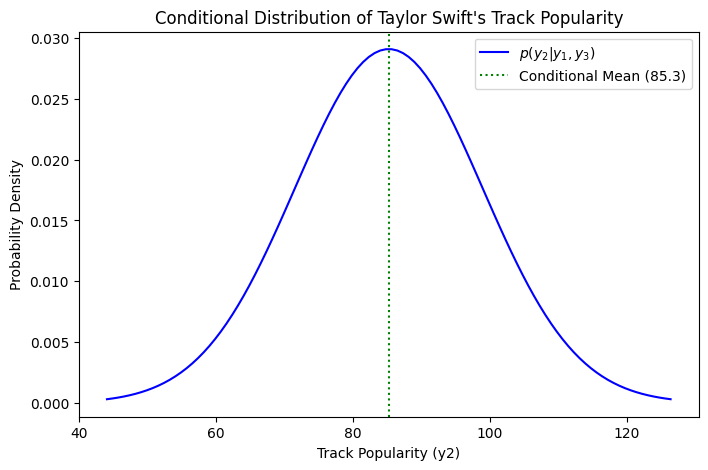

In [12]:
x_line = np.linspace(mu_agb - 3 * np.sqrt(Sigma_agb),
                     mu_agb + 3 * np.sqrt(Sigma_agb), 100)

p_agb = norm.pdf(x_line, mu_agb, np.sqrt(Sigma_agb))

plt.figure(figsize=(8, 5))
plt.plot(x_line, p_agb, label=r'$p(y_2 | y_1, y_3)$', color='blue')
plt.axvline(x=mu_agb, color='green', linestyle=':', label=f'Conditional Mean ({mu_agb:.1f})')
plt.xlabel('Track Popularity (y2)')
plt.ylabel('Probability Density')
plt.title("Conditional Distribution of Taylor Swift's Track Popularity")
plt.legend()
plt.show()